# t-SNE proection: Before vs After Transformer

This notebook loads EEGFormer checkpoints from the 5-fold run and plots token embeddings **before** (`to_tokens`) and **after** (`encoder`) the transformer using t-SNE.

In [31]:
from pathlib import Path
import json
import h5py
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models import EEGDataset_ADHD_TF, build_epoch_arrays, build_model

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

N_FOLDS = 5
BATCH_SIZE = 64
EXCLUDED_SUBJECTS = {"v56p"}

DATA_ROOT = PROJECT_ROOT / "data"
RUN_ROOT = PROJECT_ROOT / "results" / "eegformer_5fold_run"
WEIGHTS_DIR = RUN_ROOT / "weights"
OPTUNA_DIR = RUN_ROOT / "optuna"
SPLIT_TRIAL_FILE = RUN_ROOT / "trial_predictions_5fold.csv"
TSNE_SAVE_ROOT = RUN_ROOT / "tsne_embeddings"
TSNE_SAVE_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Saving t-SNE plots to: {TSNE_SAVE_ROOT}")

Project root: /var/home/automatica/Documents/GitHub/EEGFormer
Saving t-SNE plots to: /var/home/automatica/Documents/GitHub/EEGFormer/results/eegformer_5fold_run/tsne_embeddings


In [32]:
def _read_group_vars(group):
    vars_group = group["vars"]
    return [vars_group[str(index)][()] for index in range(len(vars_group))]


def load_model_from_h5_weights(model, weights_path):
    with h5py.File(weights_path, "r") as handle:
        layers_group = handle["layers"]

        layer_map = {
            "eeg_temporal": ("conv2d", None),
            "bn_t": ("batch_normalization", None),
            "eeg_depthwise": ("depthwise_conv2d", None),
            "bn_dw": ("batch_normalization_1", None),
            "eeg_separable": ("separable_conv2d", None),
            "bn_sep": ("batch_normalization_2", None),
            "attn_pool": ("attention_pooling", "attn"),
            "classifier": ("dense", None),
        }

        for layer_name, (file_layer_name, nested_name) in layer_map.items():
            layer = model.get_layer(layer_name)
            layer_group = layers_group[file_layer_name]
            weights = _read_group_vars(layer_group if nested_name is None else layer_group[nested_name])
            layer.set_weights(weights)

        encoder = model.get_layer("encoder")
        encoder_group = layers_group["transformer_encoder"]

        for i, encoder_layer in enumerate(encoder.layers_):
            if i == 0:
                block_name = "transformer_encoder_layer"
            else:
                block_name = f"transformer_encoder_layer_{i}"

            block_group = encoder_group["layers"][block_name]
            encoder_layer.norm1.set_weights(_read_group_vars(block_group["norm1"]))
            encoder_layer.norm2.set_weights(_read_group_vars(block_group["norm2"]))

            ffn_group = block_group["ffn"]["layers"]
            encoder_layer.ffn.layers[0].set_weights(_read_group_vars(ffn_group["dense"]))
            encoder_layer.ffn.layers[2].set_weights(_read_group_vars(ffn_group["dense_1"]))

            attn_group = block_group["self_attn"]
            encoder_layer.self_attn._query_dense.set_weights(_read_group_vars(attn_group["query_dense"]))
            encoder_layer.self_attn._key_dense.set_weights(_read_group_vars(attn_group["key_dense"]))
            encoder_layer.self_attn._value_dense.set_weights(_read_group_vars(attn_group["value_dense"]))
            encoder_layer.self_attn._output_dense.set_weights(_read_group_vars(attn_group["output_dense"]))

    return model


def load_hp_for_fold(fold_id):
    hp_path = OPTUNA_DIR / f"best_hp_fold_{fold_id}.json"
    with open(hp_path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def build_model_from_hp(hp, n_channels, n_samples):
    d_model = None if int(hp.get("use_proj", 0)) == 0 else int(hp["d_model"])
    return build_model(
        n_channels=n_channels,
        n_samples=n_samples,
        F1=int(hp["F1"]),
        D=int(hp["D"]),
        F2=int(hp["F2"]),
        kern_length=int(hp["kern_length"]),
        pool1=int(hp["pool1"]),
        pool2=int(hp["pool2"]),
        eeg_activation=str(hp["eeg_activation"]),
        d_model=d_model,
        nhead=int(hp["nhead"]),
        dim_feedforward=int(hp["dim_feedforward"]),
        num_layers=int(hp["num_layers"]),
        do_rate_transf=float(hp["do_rate_transf"]),
        do_rate_eeg=float(hp["do_rate_eeg"]),
        do_rate_cls=float(hp["do_rate_cls"]),
    )


def load_model_for_fold(fold_id, n_channels, n_samples):
    hp = load_hp_for_fold(fold_id)
    model = build_model_from_hp(hp, n_channels, n_samples)
    _ = model(tf.zeros((1, n_channels, n_samples), dtype=tf.float32), training=False)
    weights_path = WEIGHTS_DIR / f"fold_{fold_id}.weights.h5"
    model = load_model_from_h5_weights(model, str(weights_path))
    return model


def build_embedding_models(model):
    pre_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("to_tokens").output)
    post_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("encoder").output)
    return pre_model, post_model


def compute_tsne(features, seed=SEED, perplexity=30):
    n, l, e = features.shape
    x = features.reshape(n * l, e)
    z = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        learning_rate="auto",
        init="pca",
    ).fit_transform(x)
    return z.reshape(n, l, 2)


def split_subjects_by_fold(split_trial_file, n_folds=N_FOLDS):
    split_df = pd.read_csv(split_trial_file)
    fold_subjects = {}
    for fold_id in range(n_folds):
        names = sorted(split_df.loc[split_df["fold"] == fold_id, "subject"].astype(str).unique())
        fold_subjects[int(fold_id)] = names
    return fold_subjects


def confidence_for_true_label(labels, probs):
    labels = labels.astype(int)
    probs = np.asarray(probs, dtype=np.float32).reshape(-1)
    p_true = np.where(labels == 1, probs, 1.0 - probs)
    return np.clip(p_true, 0.0, 1.0)


def build_rgba_colors(labels, probs, alpha_min=0.05, alpha_max=0.95):
    labels = labels.astype(int)
    p_true = confidence_for_true_label(labels, probs)
    alpha = alpha_min + (alpha_max - alpha_min) * p_true

    control_rgb = np.array([31 / 255.0, 119 / 255.0, 180 / 255.0], dtype=np.float32)
    adhd_rgb = np.array([255 / 255.0, 127 / 255.0, 14 / 255.0], dtype=np.float32)

    colors = np.zeros((len(labels), 4), dtype=np.float32)
    idx0 = labels == 0
    idx1 = labels == 1
    colors[idx0, :3] = control_rgb
    colors[idx1, :3] = adhd_rgb
    colors[:, 3] = alpha.astype(np.float32)
    return colors


def build_subject_colors(subject_ids, alpha=0.9):
    """alpha can be a scalar or a per-trial array of the same length as subject_ids."""
    subject_ids = np.asarray(subject_ids).astype(str)
    unique_subjects = np.unique(subject_ids)
    cmap = plt.get_cmap("tab20", len(unique_subjects))

    subject_to_color = {subject: cmap(i) for i, subject in enumerate(unique_subjects)}
    colors = np.array([subject_to_color[subject] for subject in subject_ids], dtype=np.float32)
    colors[:, 3] = np.asarray(alpha, dtype=np.float32)
    return colors


def save_tsne_pair(z_pre, z_post, labels, probs, out_dir, title_prefix, subjects, trial_order):
    out_dir.mkdir(parents=True, exist_ok=True)

    n, l, _ = z_pre.shape
    y = np.repeat(labels.astype(int), l)
    p = np.repeat(np.asarray(probs).reshape(-1), l)

    pre2d = z_pre.reshape(n * l, 2)
    post2d = z_post.reshape(n * l, 2)
    colors = build_rgba_colors(y, p, alpha_min=0.05, alpha_max=0.95)

    subject_ids = np.repeat(np.asarray(subjects).astype(str), l)
    # Alpha proportional to classification confidence:
    # high alpha = well classified (p_true high), low alpha = poorly classified
    p_true = confidence_for_true_label(y, p)
    subject_alpha = (0.05 + 0.90 * p_true).astype(np.float32)
    subject_colors = build_subject_colors(subject_ids, alpha=subject_alpha)

    trial_vals = np.repeat(np.asarray(trial_order, dtype=np.float32), l)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=False, sharey=False)
    axes = axes.ravel()

    for ax, z2d, name in [
        (axes[0], pre2d, "Before Transformer"),
        (axes[1], post2d, "After Transformer"),
    ]:
        idx0 = y == 0
        idx1 = y == 1

        ax.scatter(
            z2d[idx0, 0],
            z2d[idx0, 1],
            s=8,
            c=colors[idx0],
            label="Control",
        )
        ax.scatter(
            z2d[idx1, 0],
            z2d[idx1, 1],
            s=8,
            c=colors[idx1],
            label="ADHD",
        )

        ax.set_title(f"{title_prefix} - {name}")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.grid(True, alpha=0.3)

    axes[2].scatter(
        post2d[:, 0],
        post2d[:, 1],
        s=8,
        c=subject_colors,
    )
    axes[2].set_title(f"{title_prefix} - After Transformer (By Subject, α = confidence)")
    axes[2].set_xlabel("Dim 1")
    axes[2].set_ylabel("Dim 2")
    axes[2].grid(True, alpha=0.3)

    temporal_scatter = axes[3].scatter(
        post2d[:, 0],
        post2d[:, 1],
        s=8,
        c=trial_vals,
        cmap="viridis",
    )
    axes[3].set_title(f"{title_prefix} - After Transformer (Temporal Causality)")
    axes[3].set_xlabel("Dim 1")
    axes[3].set_ylabel("Dim 2")
    axes[3].grid(True, alpha=0.3)
    cbar = fig.colorbar(temporal_scatter, ax=axes[3], fraction=0.046, pad=0.04)
    cbar.set_label("Window Epoch Index\n(per subject)")

    axes[1].legend(loc="best")
    fig.tight_layout()

    base_name = title_prefix.lower().replace(' ', '_')
    fig.savefig(out_dir / f"{base_name}_tsne_2x2.png", dpi=300)
    plt.show()

    np.save(out_dir / f"{base_name}_z_pre.npy", z_pre)
    np.save(out_dir / f"{base_name}_z_post.npy", z_post)

In [36]:
def save_tsne_pair(z_pre, z_post, labels, probs, out_dir, title_prefix, subjects, trial_order=None):
    out_dir.mkdir(parents=True, exist_ok=True)

    n, l, _ = z_pre.shape
    y = np.repeat(labels.astype(int), l)
    p = np.repeat(np.asarray(probs).reshape(-1), l)

    pre2d = z_pre.reshape(n * l, 2)
    post2d = z_post.reshape(n * l, 2)

    class_colors = build_rgba_colors(y, p, alpha_min=0.05, alpha_max=0.95)

    subject_ids = np.repeat(np.asarray(subjects).astype(str), l)
    p_true = confidence_for_true_label(y, p)
    subject_alpha = (0.05 + 0.90 * p_true).astype(np.float32)
    subject_colors = build_subject_colors(subject_ids, alpha=subject_alpha)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=False, sharey=False)

    # Row 1: Before Transformer (left: class, right: subject)
    ax = axes[0, 0]
    idx0 = y == 0
    idx1 = y == 1
    ax.scatter(pre2d[idx0, 0], pre2d[idx0, 1], s=8, c=class_colors[idx0], label="Control")
    ax.scatter(pre2d[idx1, 0], pre2d[idx1, 1], s=8, c=class_colors[idx1], label="ADHD")
    ax.set_title(f"{title_prefix} - Before Transformer (By Class)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    ax = axes[0, 1]
    ax.scatter(pre2d[:, 0], pre2d[:, 1], s=8, c=subject_colors)
    ax.set_title(f"{title_prefix} - Before Transformer (By Subject, alpha=confidence)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True, alpha=0.3)

    # Row 2: After Transformer (left: class, right: subject)
    ax = axes[1, 0]
    ax.scatter(post2d[idx0, 0], post2d[idx0, 1], s=8, c=class_colors[idx0], label="Control")
    ax.scatter(post2d[idx1, 0], post2d[idx1, 1], s=8, c=class_colors[idx1], label="ADHD")
    ax.set_title(f"{title_prefix} - After Transformer (By Class)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    ax = axes[1, 1]
    ax.scatter(post2d[:, 0], post2d[:, 1], s=8, c=subject_colors)
    ax.set_title(f"{title_prefix} - After Transformer (By Subject, alpha=confidence)")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    base_name = title_prefix.lower().replace(" ", "_")
    fig.savefig(out_dir / f"{base_name}_tsne_2x2.png", dpi=300)
    plt.show()

    np.save(out_dir / f"{base_name}_z_pre.npy", z_pre)
    np.save(out_dir / f"{base_name}_z_post.npy", z_post)

In [33]:
dataset = EEGDataset_ADHD_TF(
    adhd_dir=str(DATA_ROOT / "ADHD"),
    control_dir=str(DATA_ROOT / "Control"),
    lowcut=0.5,
    highcut=60.0,
    notch=50.0,
    window=2.0,
    overlap=0.5,
    default_fs=128,
)

dataset.samples = [
    sample for sample in dataset.samples if Path(sample[0]).stem not in EXCLUDED_SUBJECTS
]

X, y, groups = build_epoch_arrays(dataset)
groups = groups.astype(str)

n_channels, n_samples = int(X.shape[1]), int(X.shape[2])
fold_subjects = split_subjects_by_fold(SPLIT_TRIAL_FILE, n_folds=N_FOLDS)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Subjects: {len(np.unique(groups))}")

X shape: (16640, 19, 256)
y shape: (16640,)
Subjects: 120


In [34]:
def run_fold_tsne(fold_id=0, perplexity=30):
    """
    Generate trial-level t-SNE visualizations with temporal causality from window construction.

    Temporal order reflects the sliding window epoch sequence WITHIN each subject:
    - Each trial's color = its epoch index within that subject (0, 1, 2, ...)
    - Reflects first window at t=0, second window at t+step, etc.
    """
    tf.keras.backend.clear_session()

    model = load_model_for_fold(fold_id, n_channels, n_samples)
    pre_model, post_model = build_embedding_models(model)

    fold_names = np.array(fold_subjects[fold_id]).astype(str)
    fold_mask = np.isin(groups, fold_names)

    x_fold = X[fold_mask]
    y_fold = y[fold_mask].astype(int)
    subject_fold = groups[fold_mask].astype(str)

    # Extract within-subject epoch indices for this fold
    # This preserves true temporal causality from window construction
    trial_order_fold = within_subject_epoch_indices[fold_mask].astype(np.int32)

    pre_embeddings = pre_model.predict(x_fold, batch_size=BATCH_SIZE, verbose=0)
    post_embeddings = post_model.predict(x_fold, batch_size=BATCH_SIZE, verbose=0)

    # Pool token embeddings so each trial maps to exactly one t-SNE point.
    pre_embeddings = pre_embeddings.mean(axis=1, keepdims=True)
    post_embeddings = post_embeddings.mean(axis=1, keepdims=True)

    z_pre = compute_tsne(pre_embeddings, perplexity=perplexity)
    z_post = compute_tsne(post_embeddings, perplexity=perplexity)

    out_dir = TSNE_SAVE_ROOT / f"fold_{fold_id}"
    probs = model.predict(x_fold, batch_size=BATCH_SIZE, verbose=0).reshape(-1)
    save_tsne_pair(
        z_pre,
        z_post,
        y_fold,
        probs=probs,
        out_dir=out_dir,
        title_prefix=f"Fold {fold_id}",
        subjects=subject_fold,
        trial_order=trial_order_fold,
    )

    return {
        "fold": fold_id,
        "n_trials": int(len(y_fold)),
        "n_subjects": int(len(np.unique(subject_fold))),
        "epoch_idx_min": int(trial_order_fold.min()),
        "epoch_idx_max": int(trial_order_fold.max()),
        "pre_shape": tuple(pre_embeddings.shape),
        "post_shape": tuple(post_embeddings.shape),
        "out_dir": str(out_dir),
    }

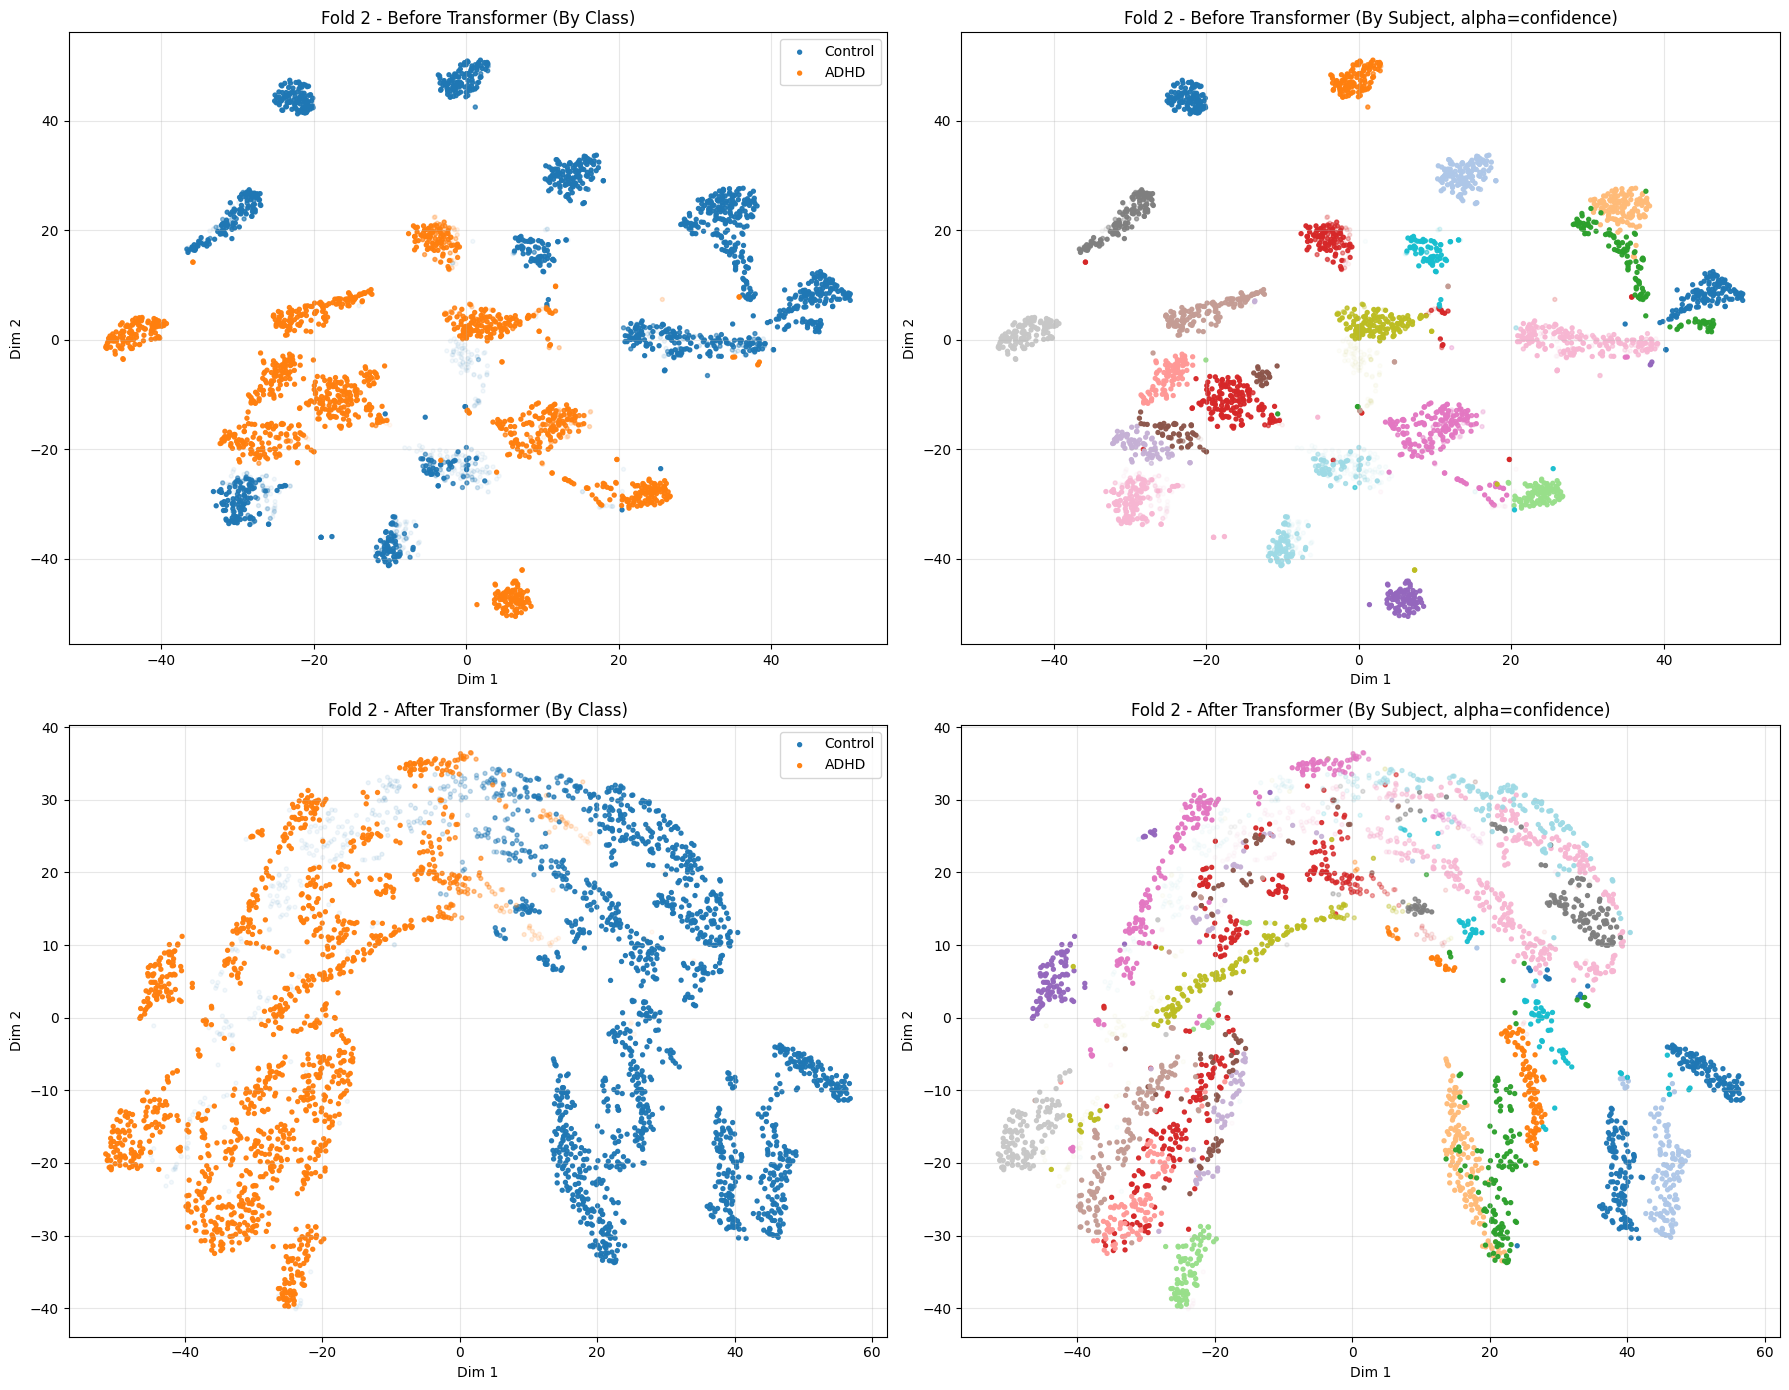

{'fold': 2,
 'n_trials': 2991,
 'n_subjects': 24,
 'epoch_idx_min': 0,
 'epoch_idx_max': 213,
 'pre_shape': (2991, 1, 48),
 'post_shape': (2991, 1, 48),
 'out_dir': '/var/home/automatica/Documents/GitHub/EEGFormer/results/eegformer_5fold_run/tsne_embeddings/fold_2'}

In [39]:
run_fold_tsne(fold_id=2, perplexity=50)

In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

def export_tsne_csv_for_fold(fold_id=2, perplexity=150):
    tf.keras.backend.clear_session()

    model = load_model_for_fold(fold_id, n_channels, n_samples)
    pre_model, post_model = build_embedding_models(model)

    fold_names = np.array(fold_subjects[fold_id]).astype(str)
    fold_mask = np.isin(groups, fold_names)

    x_fold = X[fold_mask]
    y_fold = y[fold_mask].astype(int)
    subject_fold = groups[fold_mask].astype(str)
    epoch_idx_fold = within_subject_epoch_indices[fold_mask].astype(int)

    pre_embeddings = pre_model.predict(x_fold, batch_size=BATCH_SIZE, verbose=0)
    post_embeddings = post_model.predict(x_fold, batch_size=BATCH_SIZE, verbose=0)

    # Pool token embeddings so each trial maps to exactly one t-SNE point.
    pre_embeddings = pre_embeddings.mean(axis=1, keepdims=True)
    post_embeddings = post_embeddings.mean(axis=1, keepdims=True)

    z_pre = compute_tsne(pre_embeddings, perplexity=perplexity)
    z_post = compute_tsne(post_embeddings, perplexity=perplexity)

    probs = model.predict(x_fold, batch_size=BATCH_SIZE, verbose=0).reshape(-1)

    n, l, _ = z_pre.shape
    y_rep = np.repeat(y_fold, l)
    p_rep = np.repeat(probs, l)
    p_true = np.where(y_rep == 1, p_rep, 1.0 - p_rep)
    alpha = 0.05 + 0.90 * p_true

    subj_rep = np.repeat(subject_fold, l)
    epoch_rep = np.repeat(epoch_idx_fold, l)

    # Numeric subject id for PGFPlots colormap.
    uniq_subj = np.unique(subj_rep)
    subj_to_id = {s: i for i, s in enumerate(uniq_subj)}
    subj_id = np.array([subj_to_id[s] for s in subj_rep], dtype=int)

    pre2d = z_pre.reshape(n * l, 2)
    post2d = z_post.reshape(n * l, 2)

    out_dir = TSNE_SAVE_ROOT / f"fold_{fold_id}" / "csv_for_tikz"
    out_dir.mkdir(parents=True, exist_ok=True)

    common = pd.DataFrame({
        "label": y_rep,
        "label_name": np.where(y_rep == 1, "ADHD", "Control"),
        "prob": p_rep,
        "p_true": p_true,
        "alpha": alpha,
        "subject": subj_rep,
        "subject_id": subj_id,
        "epoch_idx": epoch_rep,
    })

    df_pre = common.copy()
    df_pre["x"] = pre2d[:, 0]
    df_pre["y"] = pre2d[:, 1]

    df_post = common.copy()
    df_post["x"] = post2d[:, 0]
    df_post["y"] = post2d[:, 1]

    # You can use df_post again for "color by subject" plot.
    df_subject = df_post.copy()

    # Export as CSV.
    df_pre.to_csv(out_dir / "tsne_before.csv", index=False)
    df_post.to_csv(out_dir / "tsne_after.csv", index=False)
    df_subject.to_csv(out_dir / "tsne_by_subject.csv", index=False)

    # Export as .dat (whitespace/tab-separated for PGFPlots/TikZ).
    df_pre.to_csv(out_dir / "tsne_before.dat", index=False, sep="\t")
    df_post.to_csv(out_dir / "tsne_after.dat", index=False, sep="\t")
    df_subject.to_csv(out_dir / "tsne_by_subject.dat", index=False, sep="\t")

    # Subject legend map.
    subject_map = pd.DataFrame({
        "subject": uniq_subj,
        "subject_id": [subj_to_id[s] for s in uniq_subj],
    })
    subject_map.to_csv(out_dir / "subject_map.csv", index=False)
    subject_map.to_csv(out_dir / "subject_map.dat", index=False, sep="\t")

    return out_dir

out_csv = export_tsne_csv_for_fold(fold_id=2, perplexity=150)
print("CSV and DAT files exported to:", out_csv)
print("Files created:")
print("  - tsne_before.csv / tsne_before.dat")
print("  - tsne_after.csv / tsne_after.dat")
print("  - tsne_by_subject.csv / tsne_by_subject.dat")
print("  - subject_map.csv / subject_map.dat")

CSV and DAT files exported to: /var/home/automatica/Documents/GitHub/EEGFormer/results/eegformer_5fold_run/tsne_embeddings/fold_2/csv_for_tikz
Files created:
  - tsne_before.csv / tsne_before.dat
  - tsne_after.csv / tsne_after.dat
  - tsne_by_subject.csv / tsne_by_subject.dat
  - subject_map.csv / subject_map.dat


In [12]:
RUN_ALL_FOLDS = False

if RUN_ALL_FOLDS:
    summaries = []
    for fold_id in range(N_FOLDS):
        print(f"Running fold {fold_id}...")
        summaries.append(run_fold_tsne(fold_id=fold_id, perplexity=100))

    pd.DataFrame(summaries)

In [16]:
# Build temporal causality mapping: epoch index WITHIN each subject
# This reflects the actual sliding window construction order
# (first window at t=0, second window offset by step, etc.)

def build_within_subject_epoch_indices(dataset, groups, y):
    """
    For each trial in the global X array, compute its epoch index within its subject.
    
    Returns array where each element is the epoch index (0, 1, 2, ...) 
    within that trial's subject (based on sliding window construction).
    """
    within_subject_epoch_idx = np.zeros(len(groups), dtype=np.int32)
    
    current_trial_idx = 0
    for subject_idx in range(len(dataset)):
        name, eeg_epochs, label = dataset[subject_idx]
        n_epochs = eeg_epochs.shape[0]
        
        # All epochs from this subject get indices 0, 1, 2, ..., n_epochs-1
        within_subject_epoch_idx[current_trial_idx:current_trial_idx + n_epochs] = np.arange(n_epochs, dtype=np.int32)
        
        current_trial_idx += n_epochs
    
    return within_subject_epoch_idx

# Build the mapping
within_subject_epoch_indices = build_within_subject_epoch_indices(dataset, groups, y)

print("=== WITHIN-SUBJECT TEMPORAL CAUSALITY ===")
print(f"Mapping built for {len(within_subject_epoch_indices)} trials")
print(f"\nExample: First 20 trials' within-subject epoch indices:")
print(within_subject_epoch_indices[:20])
print(f"\nFirst 5 subjects' epoch counts:")
for i in range(min(5, len(dataset))):
    name, eeg_epochs, label = dataset[i]
    n_epochs = eeg_epochs.shape[0]
    print(f"  {name}: {n_epochs} epochs → indices 0 to {n_epochs-1}")


=== WITHIN-SUBJECT TEMPORAL CAUSALITY ===
Mapping built for 16640 trials

Example: First 20 trials' within-subject epoch indices:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

First 5 subjects' epoch counts:
  v10p.mat: 110 epochs → indices 0 to 109
  v12p.mat: 136 epochs → indices 0 to 135
  v14p.mat: 136 epochs → indices 0 to 135
  v15p.mat: 336 epochs → indices 0 to 335
  v173.mat: 188 epochs → indices 0 to 187
